In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()

In [2]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

data_dir = 'data/hymenoptera_data'

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                  for x in ['train', 'val']}

dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4, shuffle=True, num_workers=4)
               for x in ['train', 'val']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}

class_names = image_datasets['train'].classes

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [16]:
def imshow(inp, title=None):
    """Display image for Tensor without forcing a pause."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)

inputs, classes = next(iter(dataloaders['train']))
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[x] for x in classes])


In [4]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')
        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()
                else:
                    model.eval()

                running_loss = 0.0
                running_corrects = 0

                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)
                    optimizer.zero_grad()
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

In [18]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    
    fig = plt.figure(figsize=(12, 8)) 

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images // 2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    plt.tight_layout() 
                    plt.show()    
                    return
        model.train(mode=was_training)

In [6]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, 2)
model_ft = model_ft.to(device)
criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\HP/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:13<00:00, 3.59MB/s]


In [7]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------
train Loss: 0.5897 Acc: 0.7213
val Loss: 0.4273 Acc: 0.8366

Epoch 1/24
----------
train Loss: 0.3977 Acc: 0.8074
val Loss: 0.2483 Acc: 0.9346

Epoch 2/24
----------
train Loss: 0.4213 Acc: 0.8525
val Loss: 0.3703 Acc: 0.8954

Epoch 3/24
----------
train Loss: 0.7116 Acc: 0.7213
val Loss: 0.5470 Acc: 0.8562

Epoch 4/24
----------
train Loss: 0.4927 Acc: 0.8238
val Loss: 0.4320 Acc: 0.8758

Epoch 5/24
----------
train Loss: 0.6268 Acc: 0.7664
val Loss: 0.3924 Acc: 0.8824

Epoch 6/24
----------
train Loss: 0.4858 Acc: 0.7951
val Loss: 0.3518 Acc: 0.8889

Epoch 7/24
----------
train Loss: 0.3084 Acc: 0.8852
val Loss: 0.2905 Acc: 0.9085

Epoch 8/24
----------
train Loss: 0.2990 Acc: 0.8689
val Loss: 0.2743 Acc: 0.9085

Epoch 9/24
----------
train Loss: 0.2593 Acc: 0.8975
val Loss: 0.2961 Acc: 0.8954

Epoch 10/24
----------
train Loss: 0.2605 Acc: 0.8934
val Loss: 0.2490 Acc: 0.9216

Epoch 11/24
----------
train Loss: 0.2997 Acc: 0.8934
val Loss: 0.2531 Acc: 0.9216

Ep

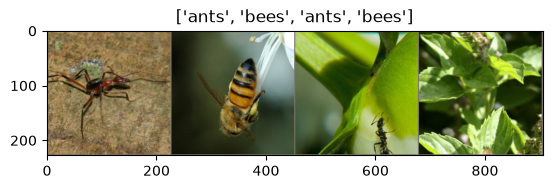

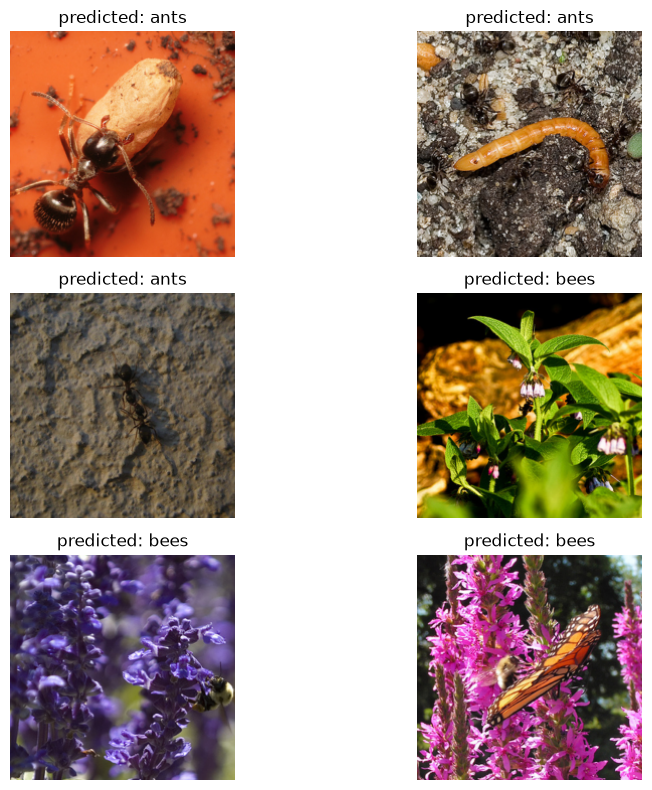

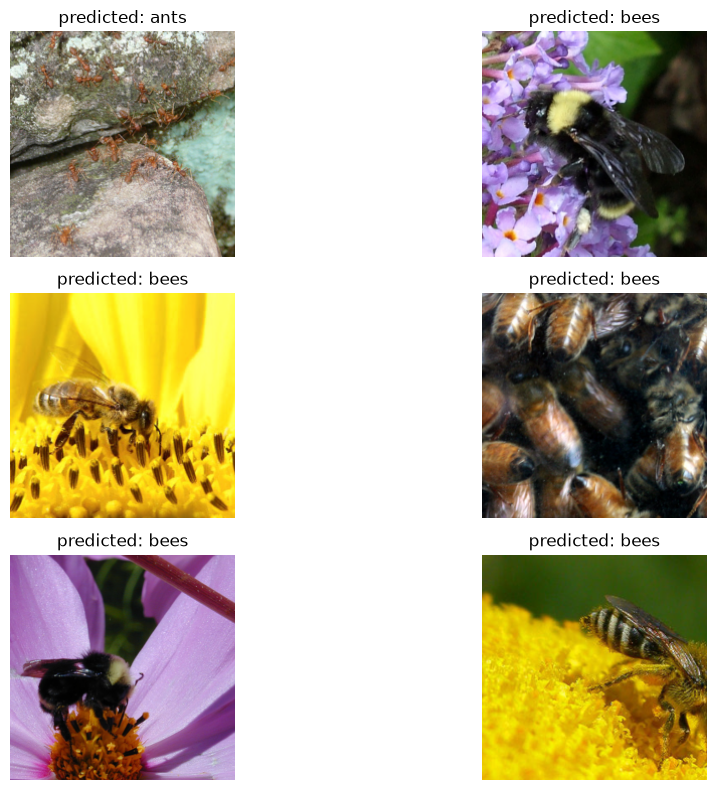

In [19]:
visualize_model(model_ft)

In [10]:
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)
model_conv = model_conv.to(device)
criterion = nn.CrossEntropyLoss()
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [11]:
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.6534 Acc: 0.6189
val Loss: 0.4469 Acc: 0.8039

Epoch 1/24
----------
train Loss: 0.5385 Acc: 0.7664
val Loss: 0.5988 Acc: 0.7582

Epoch 2/24
----------
train Loss: 0.6988 Acc: 0.7541
val Loss: 0.4527 Acc: 0.8170

Epoch 3/24
----------
train Loss: 0.6583 Acc: 0.7213
val Loss: 0.1818 Acc: 0.9477

Epoch 4/24
----------
train Loss: 0.4050 Acc: 0.8361
val Loss: 0.2132 Acc: 0.9412

Epoch 5/24
----------
train Loss: 0.5581 Acc: 0.7541
val Loss: 0.1831 Acc: 0.9542

Epoch 6/24
----------
train Loss: 0.4911 Acc: 0.7951
val Loss: 0.1856 Acc: 0.9477

Epoch 7/24
----------
train Loss: 0.4073 Acc: 0.8197
val Loss: 0.2121 Acc: 0.9412

Epoch 8/24
----------
train Loss: 0.4276 Acc: 0.8443
val Loss: 0.2022 Acc: 0.9281

Epoch 9/24
----------
train Loss: 0.4195 Acc: 0.8197
val Loss: 0.2608 Acc: 0.9346

Epoch 10/24
----------
train Loss: 0.3959 Acc: 0.8484
val Loss: 0.2047 Acc: 0.9346

Epoch 11/24
----------
train Loss: 0.4033 Acc: 0.8197
val Loss: 0.1666 Acc: 0.9477

Ep

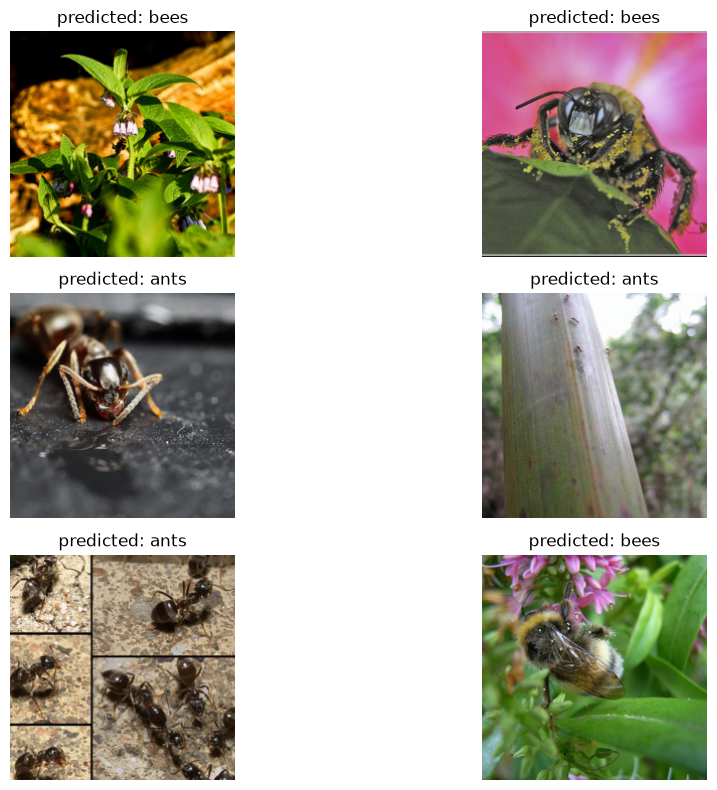

In [22]:
visualize_model(model_conv)

plt.ioff()
plt.show()